### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

### Load and Inspect Data

In [ ]:
# Read data
df = pd.read_csv(r"/home/ceejay/Documents/Code/Robotics/practice-ai/datasets/messy_dataset_50.csv")

# Create a copy to work on
df_copy = df.copy()

In [5]:
# View first five row
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57,grace@mail.com,18-08-2022,"55,000",Admin
1,2,Bob,twenty,invalidemail.com,NaN,"49,000",IT
2,3,frank,34,NaN,16-02-2020,"69,000",Admin
3,4,Isabel,NaN,isabel@mail.com,08-10-2020,NaN,it
4,5,davi,31,davi@mail,2022-12-20,78828,Marketing


In [6]:
# View last five row
df_copy.tail()

,ID,Name,Age,Email,Join_Date,Salary,Department
45,46,Henry,29 years,NaN,NaN,53454,finance
46,47,Alice,thirty,alice@@mail.com,NaN,NaN,Finance
47,48,Charle,46,invalidemail.com,not_a_date,sixty thousand,hr
48,49,David,27 years,invalidemail.com,not_a_date,34431,Admin
49,50,Grace,59,grace@mail,2023-05-21,60245,NaN


In [8]:
# Check shape
df_copy.shape

(50, 7)

In [9]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          50 non-null     int64
 1   Name        50 non-null     str  
 2   Age         45 non-null     str  
 3   Email       37 non-null     str  
 4   Join_Date   31 non-null     str  
 5   Salary      30 non-null     str  
 6   Department  39 non-null     str  
dtypes: int64(1), str(6)
memory usage: 2.9 KB


In [10]:
df_copy.describe()

,ID
count,50.00000
mean,25.50000
std,14.57738
min,1.00000
25%,13.25000
50%,25.50000
75%,37.75000
max,50.00000


In [11]:
df_copy.describe(include="all")

,ID,Name,Age,Email,Join_Date,Salary,Department
count,50.00000,50,45,37,31,30,39
unique,NaN,27,33,23,27,19,14
top,NaN,Grace,57,invalidemail.com,not_a_date,sixty thousand,Admin
freq,NaN,7,3,8,5,12,7
mean,25.50000,NaN,NaN,NaN,NaN,NaN,NaN
std,14.57738,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN
25%,13.25000,NaN,NaN,NaN,NaN,NaN,NaN
50%,25.50000,NaN,NaN,NaN,NaN,NaN,NaN
75%,37.75000,NaN,NaN,NaN,NaN,NaN,NaN


### Clean Data

#### Text to number

* Age - text to number conversion

In [12]:
# Check unique values in age column
df_copy["Age"].unique()

<StringArray>
[      '57',   'twenty',       '34',        nan,       '31', '60 years',
       '60',       '58', '50 years', '53 years', '43 years',   'thirty',
       '55',       '40',       '54',       '56',       '21', '45 years',
 '49 years', '22 years', '38 years', '30 years', '41 years',       '38',
       '20', '42 years', '36 years',       '36', '28 years', '26 years',
 '29 years',       '46', '27 years',       '59']
Length: 34, dtype: str

In [13]:
# Change "twenty", "thirty" to 20 and 30 respectivelu
df_copy["Age"] = df_copy["Age"].str.replace("twenty", "20")
df_copy["Age"] = df_copy["Age"].str.replace("thirty", "30")

In [14]:
# Remove "years" at the back of the age
df_copy["Age"] = df_copy["Age"].str.replace("years", "", regex=False)

In [15]:
# Let's see unique value again
df_copy["Age"].unique()

<StringArray>
[ '57',  '20',  '34',   nan,  '31', '60 ',  '60',  '58', '50 ', '53 ', '43 ',
  '30',  '55',  '40',  '54',  '56',  '21', '45 ', '49 ', '22 ', '38 ', '30 ',
 '41 ',  '38', '42 ', '36 ',  '36', '28 ', '26 ', '29 ',  '46', '27 ',  '59']
Length: 33, dtype: str

* Salary text conversion

In [16]:
df_copy["Salary"].unique()

<StringArray>
[        '55,000',         '49,000',         '69,000',              nan,
          '78828', 'sixty thousand',         '44,000',          '33033',
          '42606',         '76,000',          '79209',          '61050',
         '60,000',          '36890',          '76284',         '59,000',
         '41,000',          '53454',          '34431',          '60245']
Length: 20, dtype: str

In [17]:
# change "sixty thousand" to "60,000"
df_copy["Salary"] = df_copy["Salary"].str.replace("sixty thousand", "60,000")

In [18]:
df_copy["Salary"].unique()

<StringArray>
['55,000', '49,000', '69,000',      nan,  '78828', '60,000', '44,000',
  '33033',  '42606', '76,000',  '79209',  '61050',  '36890',  '76284',
 '59,000', '41,000',  '53454',  '34431',  '60245']
Length: 19, dtype: str

In [19]:
# View data
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57,grace@mail.com,18-08-2022,"55,000",Admin
1,2,Bob,20,invalidemail.com,NaN,"49,000",IT
2,3,frank,34,NaN,16-02-2020,"69,000",Admin
3,4,Isabel,NaN,isabel@mail.com,08-10-2020,NaN,it
4,5,davi,31,davi@mail,2022-12-20,78828,Marketing


#### Format Inconsistencies

* Name have inconsistent capitalization and trailing spaces

In [20]:
# Check unique names
df_copy["Name"].unique()

<StringArray>
[  'Grace',     'Bob',   'frank', 'Isabel ',    'davi',    'Alic', 'Charles',
   'Isabe',   'Henry',   'alice',    'grac',   'David',   'david',    'Jack',
     'Eve',     'bob',   'henry',    'Fran',   'Jack ',  'isabel',    'jack',
   'Alice',  'David ',    'Grac',  'Isabel',   'Frank',  'Charle']
Length: 27, dtype: str

In [21]:
# Trim spaces using .str.strip()
# Fix casing using str.title()
df_copy['Name'] = df_copy['Name'].str.strip().str.title()

In [22]:
df_copy["Name"].unique()

<StringArray>
[  'Grace',     'Bob',   'Frank',  'Isabel',    'Davi',    'Alic', 'Charles',
   'Isabe',   'Henry',   'Alice',    'Grac',   'David',    'Jack',     'Eve',
    'Fran',  'Charle']
Length: 16, dtype: str

* Department have inconsistent capitalization and abbreviation

In [23]:
# Check unique department
df_copy["Department"].unique()

<StringArray>
[    'Admin',        'IT',        'it', 'Marketing', 'MARKETING',         nan,
     'SALES',   'Finance', 'marketing',        'hr',     'ADMIN',   'finance',
     'sales',     'admin',     'Sales']
Length: 15, dtype: str

In [24]:
# Trim spaces using .str.strip()
# Fix casing using str.title()
df_copy['Department'] = df_copy['Department'].str.strip().str.title()

In [25]:
# Change abbreviations to uppercase
df_copy["Department"] = df_copy["Department"].replace({"It": "IT", "Hr": "HR"})

In [26]:
df_copy["Department"].unique()

<StringArray>
['Admin', 'IT', 'Marketing', nan, 'Sales', 'Finance', 'HR']
Length: 7, dtype: str

* Remove commas and possible trailing spaces in Salary

In [27]:
# Remove the commas
df_copy["Salary"] = df_copy["Salary"].str.replace(",", "")

# Remove the trailing spaces
df_copy["Salary"] = df_copy["Salary"].str.strip()

In [28]:
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57,grace@mail.com,18-08-2022,55000,Admin
1,2,Bob,20,invalidemail.com,NaN,49000,IT
2,3,Frank,34,NaN,16-02-2020,69000,Admin
3,4,Isabel,NaN,isabel@mail.com,08-10-2020,NaN,IT
4,5,Davi,31,davi@mail,2022-12-20,78828,Marketing


#### Fix Data Types

In [29]:
df_copy.info()


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          50 non-null     int64
 1   Name        50 non-null     str  
 2   Age         45 non-null     str  
 3   Email       37 non-null     str  
 4   Join_Date   31 non-null     str  
 5   Salary      30 non-null     str  
 6   Department  39 non-null     str  
dtypes: int64(1), str(6)
memory usage: 2.9 KB


In [ ]:
# Convert Age to numeric
# 'errors=' replaces unconvertible data to NaN
df_copy["Age"] = pd.to_numeric(df_copy["Age"], errors="coerce")

# Convert Salary to numeric
df_copy["Salary"] = pd.to_numeric(df_copy["Salary"], errors="coerce")

# Convert Join_Date to datetime
def parse_date(value):
    """
    A function that converts date in
    """

    # If already a datetime, return it
    if isinstance(value, pd.Timestamp):
        return value

    # Handle missing values
    if pd.isna(value):
        return pd.NaT

    # Try parsing string dates
    value = str(value).strip()

    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%Y/%m/%d", "%m/%d/%Y"):
        try:
            return datetime.strptime(value, fmt)
        except ValueError:
            continue

    # If all parsing fails
    return pd.NaT

# Call function
df_copy["Join_Date"] = df_copy["Join_Date"].apply(parse_date)


In [31]:
# Check info again
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ID          50 non-null     int64         
 1   Name        50 non-null     str           
 2   Age         45 non-null     float64       
 3   Email       37 non-null     str           
 4   Join_Date   26 non-null     datetime64[us]
 5   Salary      30 non-null     float64       
 6   Department  39 non-null     str           
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 2.9 KB


In [32]:
# view dataframe
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57.0,grace@mail.com,2022-08-18,55000.0,Admin
1,2,Bob,20.0,invalidemail.com,NaT,49000.0,IT
2,3,Frank,34.0,NaN,2020-02-16,69000.0,Admin
3,4,Isabel,NaN,isabel@mail.com,2020-10-08,NaN,IT
4,5,Davi,31.0,davi@mail,2022-12-20,78828.0,Marketing


#### Handle Missing Value

In [34]:
# Replace Null or Nan string value in the data with an actual NAN recognized by Python using np.nan
df_copy.replace(["NULL", "NaN", "nan", "None", "NAN", "NaT"], np.nan, inplace=True)

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57.0,grace@mail.com,2022-08-18,55000.0,Admin
1,2,Bob,20.0,invalidemail.com,NaT,49000.0,IT
2,3,Frank,34.0,NaN,2020-02-16,69000.0,Admin
3,4,Isabel,NaN,isabel@mail.com,2020-10-08,NaN,IT
4,5,Davi,31.0,davi@mail,2022-12-20,78828.0,Marketing
5,6,Alic,57.0,alic@mail.com,2022-03-03,60000.0,Marketing
6,7,Charles,60.0,invalidemail.com,NaT,60000.0,Admin
7,8,Isabel,57.0,isabel@mail.com,2022-06-10,NaN,NaN
8,9,Bob,60.0,bob@mail.com,2021-06-08,60000.0,Sales
9,10,Grace,58.0,invalidemail.com,2021-07-22,NaN,Finance


In [35]:
# Check how many missing value using isna or isnull
df_copy.isna().sum()

ID             0
Name           0
Age            5
Email         13
Join_Date     24
Salary        20
Department    11
dtype: int64

In [ ]:
# We drop critical ones
df_copy.dropna(subset=["ID", "Name", "Email", "Join_Date"], inplace=True)

# Impute non-critical ones

# Let's fill in the missing value with mean age
df_copy["Age"] = df_copy["Age"].fillna(round(df_copy["Age"].mean()))

# Let's fill in the missing value with mean salary
df_copy["Salary"] = df_copy["Salary"].fillna(round(df_copy["Salary"].mean()))

# Let's fill in the missing value for department with Unknown
df_copy["Department"] = df_copy["Department"].fillna('Unknown')

In [37]:
# Check for missing value again
df_copy.isna().sum()

ID            0
Name          0
Age           0
Email         0
Join_Date     0
Salary        0
Department    0
dtype: int64

In [ ]:
# Convert age to int
df_copy["Age"] = df_copy["Age"].astype(int)

In [39]:
df_copy.shape

(21, 7)

#### Duplicate Entries

In [40]:
# Check for duplicates
print(df_copy.duplicated().sum())

0


* `df_copy.drop_duplicates(subset=['ID'], keep='first', inplace=True)` to drop duplicates

#### Check for Outliers

In [41]:
df_copy.describe()

,ID,Age,Join_Date,Salary
count,21.000000,21.000000,21,21.000000
mean,21.095238,44.142857,2021-12-08 06:51:25.714285,59764.285714
min,1.000000,21.000000,2020-02-14 00:00:00,41000.000000
25%,9.000000,36.000000,2021-03-28 00:00:00,59764.000000
50%,18.000000,44.000000,2022-03-03 00:00:00,59764.000000
75%,35.000000,57.000000,2022-11-16 00:00:00,60000.000000
max,50.000000,60.000000,2023-11-27 00:00:00,79209.000000
std,15.059564,12.539082,NaN,9811.910640


In [42]:
# Use IQR(Interquatile range) to detect outlier
Q1 = df_copy['Age'].quantile(0.25)
Q3 = df_copy['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy['Age'] < lower_bound) | (df_copy['Age'] > upper_bound)]

# View outliers if any
print(outliers)


Empty DataFrame
Columns: [ID, Name, Age, Email, Join_Date, Salary, Department]
Index: []


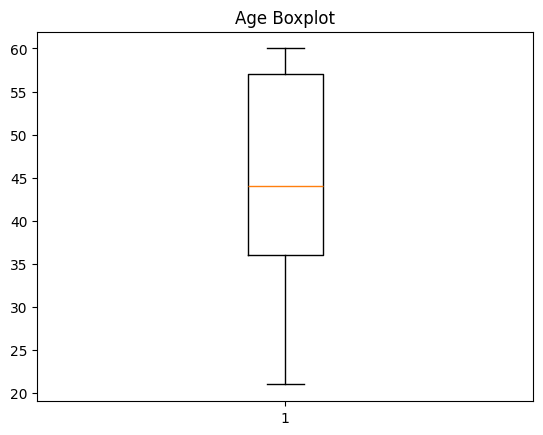

In [43]:
# Visual confirmation
plt.boxplot(df_copy['Age'])
plt.title("Age Boxplot")
plt.show()

### Save Cleaned Data

In [45]:
df_copy.to_csv("/home/ceejay/Documents/Code/Robotics/practice-ai/datasets/cleaned_data.csv", index=False)